In [2]:
import numpy as np
import matplotlib.pyplot as plt

#np.random.seed(42)
n_sim=50
s=0.1


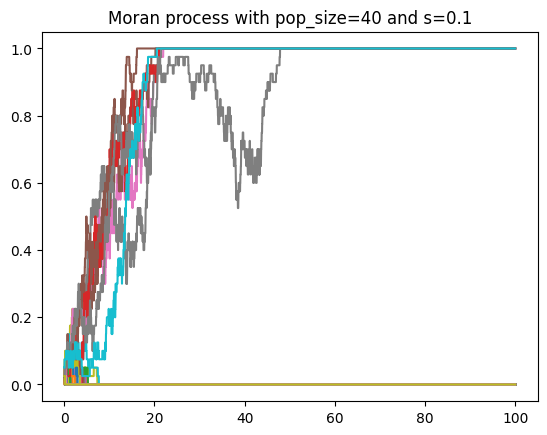

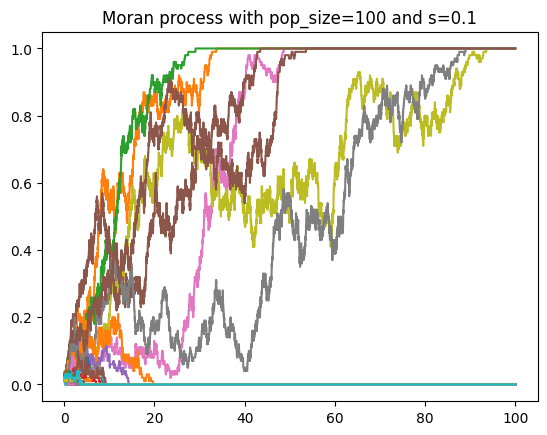

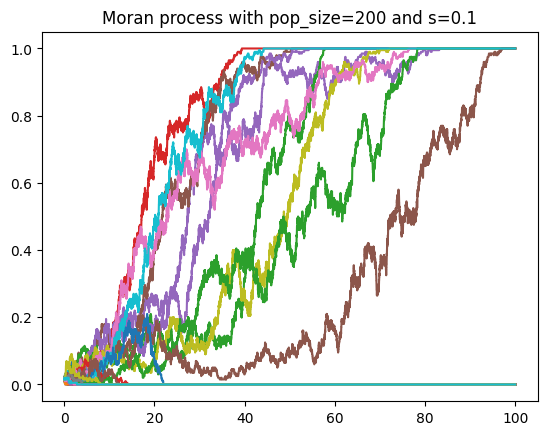

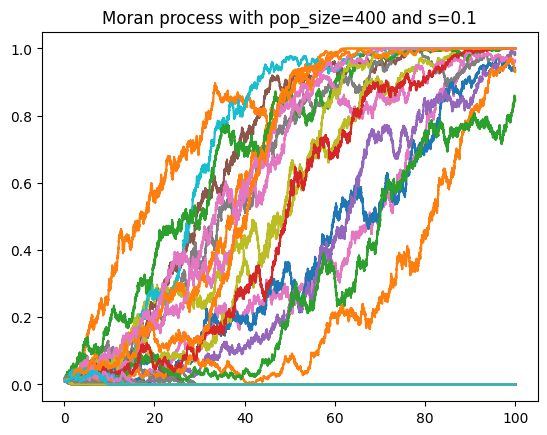

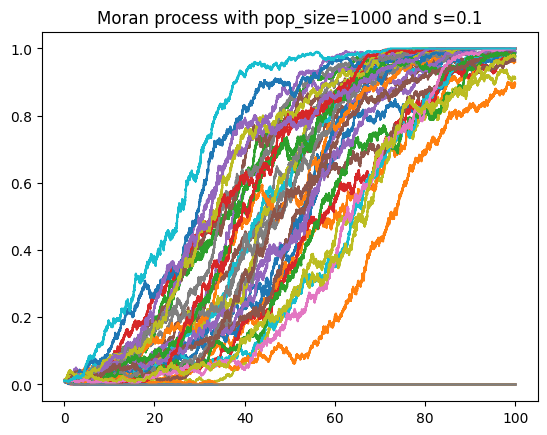

In [3]:
for pop_size in [40,100,200,400,1000]:
    b_size=0.01
    t=np.arange(0,100*pop_size) #100 generations

    for sim in range(n_sim):
        
        x=np.zeros(pop_size) 
        num_b=int(b_size*pop_size)+1
        x[0:num_b]=1 #population full of population a with one b individual
        
        num_a=pop_size-num_b
        
        b_plot = np.zeros(np.size(t))
    
        for i in t:
            
            if num_b==0 or num_b==pop_size: #if all b dies or all a dies
                b_plot[i:]=num_b/pop_size
                break
            
            fitness_a=1.0
            fitness_b=1.0+s
            tot_fitness=(num_a*fitness_a)+(num_b*fitness_b)
            p_rep_b=(num_b*fitness_b)/tot_fitness

            if np.random.random() < p_rep_b:
                born_val=1
            else:
                born_val=0

            dead_idx=np.random.randint(0,pop_size)
            dead_val=x[dead_idx]
            if dead_val != born_val:
                x[dead_idx]=born_val
                if born_val == 1:
                    num_b+=1
                    num_a-=1
                else:
                    num_b-=1
                    num_a+=1
            prob_b=np.sum(x)/pop_size
        
            # a_plot[i]=prob_a
            b_plot[i]=prob_b
        plt.figure(pop_size)
        #plt.axis([0,100,0,1])
        plt.title('Moran process with pop_size='+str(pop_size)+' and s='+str(s))
        plt.plot(t/pop_size,b_plot)
    plt.show()

The implementation choice here is that the mutant individuals are introduced as a rare variant (1% of the population). Due to this choice, some simulations points quite instantly towards zero because we are in the unlucky case where mutant population is killed before having the possibility to spread.

By the way, we can observe that in small populations the dynamics are dominated by genetic drift (stochasticity). Despite the 10% fitness advantage, the randomness of the death process leads easier to the extinction of the mutant population. However, if the mutant survives the initial steps, it grows very rapidly until the saturation is reached (no more non-mutated individuals are alive). The graphics show "zig-zag" lines with two final possibilities: rapid extinction or rapid fixation.
As the population size increases, the effect of genetic drift is less visible, and the dynamics become more deterministic. In these graphics, we observe smoother curves similar to logistic curves. While the initial extinction cases still happen (but with much less probability), once the mutant establishes, its frequency increases steadily over time. As seen in the previus versions of the code, the "noise" in the graph decreases significantlyas the population grows.

We can also notice that in larger population, more time is needed to "win" because mutant population has to replace a much large number of non-mutant individuals.